# Visualisasi Marker EDF: ALS vs Normal

Notebook ini membedah **annotations/marker** dari file EDF dalam dataset ZIP,
lalu membandingkan struktur marker antara subjek **ALS** dan **Normal**.

**Yang divisualisasikan:**
1. Daftar marker (task) per file
2. Timeline marker per file
3. Distribusi durasi task (ALS vs Normal)
4. Jumlah task per subjek
5. Perbandingan statistik durasi

In [3]:
!pip install seaborn

In [4]:
import sys
import os
import zipfile
import tempfile
import re

import mne  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

mne.set_log_level("ERROR")
sns.set_theme(style="darkgrid")

print("Libraries loaded.")

Libraries loaded.


## 1. Konfigurasi

Ganti `ZIP_PATH` dengan path ke file ZIP dataset kamu.

In [5]:
# ====== GANTI PATH INI ======
ZIP_PATH = r"C:\Users\Henry\Documents\KULIAH\riset\EEG\dummy.zip"  # Path ke file ZIP dataset
# ============================

TASK_COLORS = {
    "Resting": "#4CAF50",
    "Thinking": "#2196F3",
    "Typing": "#FF9800",
    "Thinking and Acting": "#E91E63",
    "Think_Acting": "#E91E63",
}
DEFAULT_COLOR = "#9E9E9E"

## 2. Fungsi Helper

In [6]:
def detect_category(edf_path):
    """Deteksi kategori (ALS/Normal) dan metadata dari path di ZIP."""
    parts = edf_path.replace("\\", "/").split("/")
    parts = [p for p in parts if p and not p.lower().endswith(".edf")]

    subject = "unknown"
    category = "Normal"
    time_val = ""
    scenario_val = ""

    for p in parts:
        p_upper = p.upper()
        p_lower = p.lower()
        if re.match(r'^ALS\d*', p_upper):
            subject = p
            category = "ALS"
        elif re.match(r'^id\d+$', p_lower) and subject == "unknown":
            subject = p
            category = "Normal"
        elif p_lower.startswith("time"):
            time_val = p
        elif p_lower.startswith("scenario"):
            scenario_val = p

    return {
        "category": category,
        "subject": subject,
        "time": time_val,
        "scenario": scenario_val,
    }


def extract_markers_from_zip(zip_path, max_files=None):
    """Baca semua file EDF dari ZIP dan ekstrak marker/annotations."""
    rows = []
    
    with zipfile.ZipFile(zip_path, 'r') as zf:
        edf_list = [f for f in zf.namelist() if f.lower().endswith('.edf')]
        if max_files:
            edf_list = edf_list[:max_files]
        
        print(f"Ditemukan {len(edf_list)} file EDF")
        
        for i, edf_path in enumerate(edf_list):
            meta = detect_category(edf_path)
            
            try:
                with tempfile.NamedTemporaryFile(suffix='.edf', delete=False) as tmp:
                    tmp.write(zf.read(edf_path))
                    tmp_path = tmp.name
                
                raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)
                
                for ann in raw.annotations:
                    desc = ann['description'].strip()
                    if not desc or desc.lower() == 'none':
                        continue
                    rows.append({
                        'file': edf_path,
                        'category': meta['category'],
                        'subject': meta['subject'],
                        'time': meta['time'],
                        'scenario': meta['scenario'],
                        'task': desc,
                        'onset': ann['onset'],
                        'duration': ann['duration'],
                        'end': ann['onset'] + ann['duration'],
                        'n_channels': len(raw.ch_names),
                        'sfreq': raw.info['sfreq'],
                        'total_duration': raw.times[-1],
                    })
                
                os.unlink(tmp_path)
                
            except Exception as e:
                print(f"  Error: {edf_path}: {e}")
                if os.path.exists(tmp_path):
                    os.unlink(tmp_path)
                continue
            
            if (i + 1) % 20 == 0:
                print(f"  Progress: {i+1}/{len(edf_list)}")
    
    print(f"Selesai! {len(rows)} marker diekstrak dari {len(edf_list)} file.")
    return pd.DataFrame(rows)

## 3. Ekstrak Marker dari ZIP

In [7]:
assert ZIP_PATH, "Isi ZIP_PATH di cell Konfigurasi terlebih dahulu!"

df = extract_markers_from_zip(ZIP_PATH)
df.head(10)

Ditemukan 177 file EDF
  Progress: 20/177


C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)


  Progress: 40/177
  Progress: 60/177
  Progress: 80/177


C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Omitted 10 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outsi

  Progress: 100/177


C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)


  Progress: 120/177
  Progress: 140/177


C:\Users\Henry\AppData\Local\Temp\ipykernel_40308\1287024815.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(tmp_path, preload=False, verbose=False)


  Progress: 160/177
Selesai! 1311 marker diekstrak dari 177 file.


,file,category,subject,time,scenario,task,onset,duration,end,n_channels,sfreq,total_duration
0,dummy/ALS02/time1/scenario1/EEG.edf,ALS,ALS02,time1,scenario1,Thinking,8.0131,11.5809,19.5940,32,128.0,114.992188
1,dummy/ALS02/time1/scenario1/EEG.edf,ALS,ALS02,time1,scenario1,Resting,19.5941,6.7117,26.3058,32,128.0,114.992188
2,dummy/ALS02/time1/scenario1/EEG.edf,ALS,ALS02,time1,scenario1,Thinking,26.3068,11.0300,37.3368,32,128.0,114.992188
3,dummy/ALS02/time1/scenario1/EEG.edf,ALS,ALS02,time1,scenario1,Resting,37.3368,8.8806,46.2174,32,128.0,114.992188
4,dummy/ALS02/time1/scenario1/EEG.edf,ALS,ALS02,time1,scenario1,Thinking,46.2174,10.8456,57.0630,32,128.0,114.992188
5,dummy/ALS02/time1/scenario1/EEG.edf,ALS,ALS02,time1,scenario1,Resting,57.0640,11.4116,68.4756,32,128.0,114.992188
6,dummy/ALS02/time1/scenario1/EEG.edf,ALS,ALS02,time1,scenario1,Typing,68.4756,45.6825,114.1581,32,128.0,114.992188
7,dummy/ALS02/time1/scenario2/EEG.edf,ALS,ALS02,time1,scenario2,Thinking,7.6310,11.2741,18.9051,32,128.0,113.992188
8,dummy/ALS02/time1/scenario2/EEG.edf,ALS,ALS02,time1,scenario2,Resting,18.9051,11.5043,30.4094,32,128.0,113.992188
9,dummy/ALS02/time1/scenario2/EEG.edf,ALS,ALS02,time1,scenario2,Thinking,30.4104,10.7285,41.1389,32,128.0,113.992188


## 4. Ringkasan Data Marker

In [8]:
print("=" * 60)
print("RINGKASAN MARKER")
print("=" * 60)
print(f"Total file    : {df['file'].nunique()}")
print(f"Total marker  : {len(df)}")
print(f"Total subjek  : {df['subject'].nunique()}")
print(f"Kategori      : {df['category'].unique().tolist()}")
print(f"\nJumlah subjek per kategori:")
print(df.groupby('category')['subject'].nunique().to_string())
print(f"\nTask unik ditemukan:")
for task in sorted(df['task'].unique()):
    count = len(df[df['task'] == task])
    print(f"  - {task}: {count} marker")
print(f"\nDurasi rata-rata per task (detik):")
print(df.groupby('task')['duration'].agg(['mean', 'std', 'min', 'max']).round(2).to_string())

RINGKASAN MARKER
Total file    : 176
Total marker  : 1311
Total subjek  : 4
Kategori      : ['ALS', 'Normal']

Jumlah subjek per kategori:
category
ALS       2
Normal    2

Task unik ditemukan:
  - Resting: 568 marker
  - Think_Acting: 10 marker
  - Thinking: 523 marker
  - Thinking and Acting: 37 marker
  - Typing: 173 marker

Durasi rata-rata per task (detik):
                      mean    std    min     max
task                                            
Resting               6.31   2.41   0.63   23.84
Think_Acting          5.22   1.63   1.04    6.73
Thinking             11.01   1.55   3.16   25.15
Thinking and Acting   7.07   2.35   1.07   14.04
Typing               38.72  16.86  11.42  138.50


## 5. Timeline Marker per File

Menampilkan timeline marker untuk beberapa file ALS dan Normal.

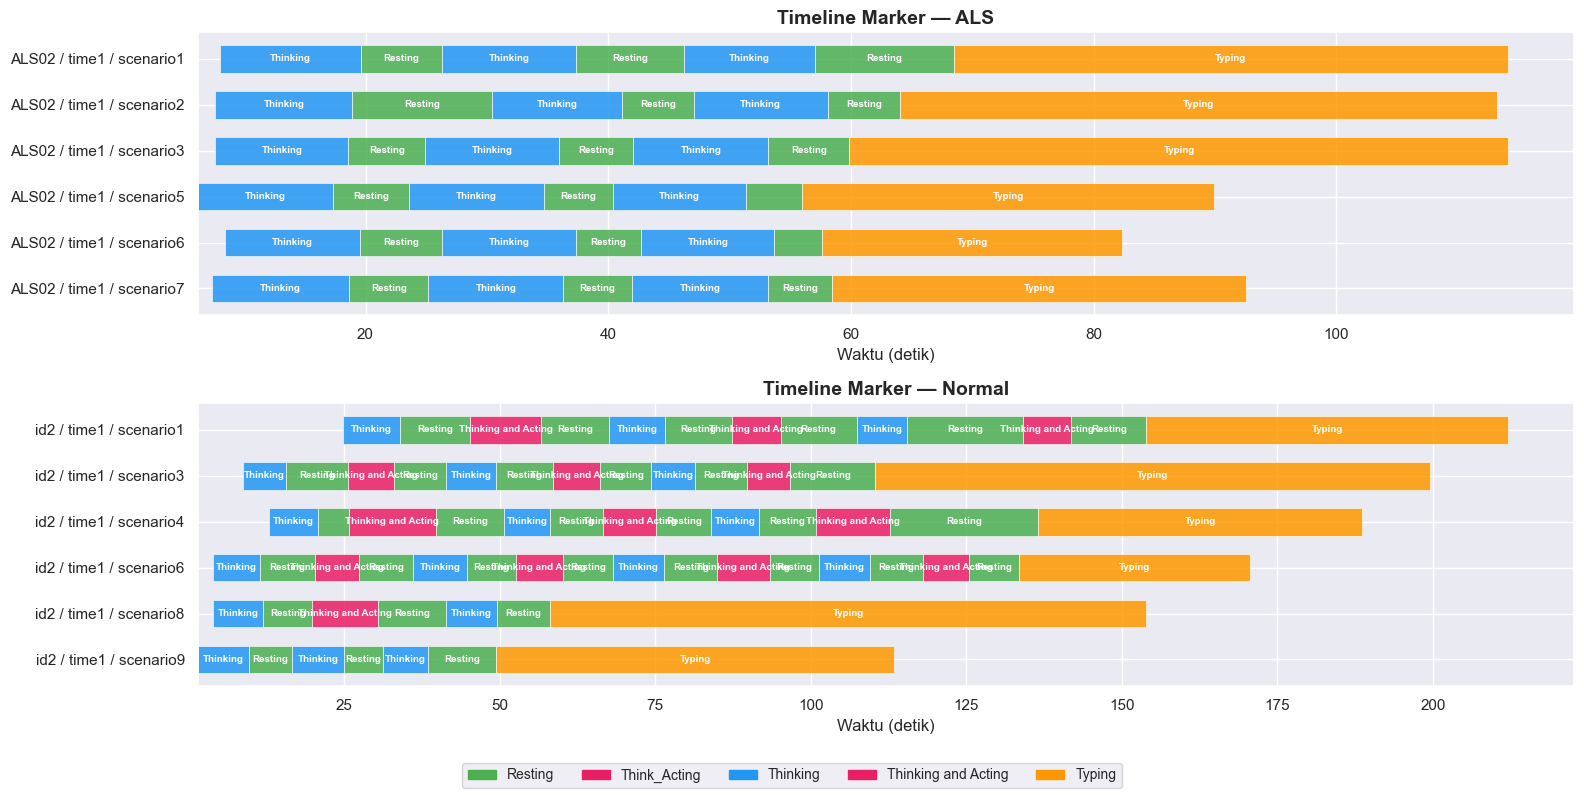

In [14]:
def plot_marker_timeline(df, n_files=5):
    """Plot timeline marker untuk n file pertama per kategori."""
    categories = sorted(df['category'].unique())
    
    fig, axes = plt.subplots(len(categories), 1, figsize=(16, 4 * len(categories)))
    if len(categories) == 1:
        axes = [axes]
    
    for ax, cat in zip(axes, categories):
        cat_df = df[df['category'] == cat]
        files = cat_df['file'].unique()[:n_files]
        
        for y_idx, f in enumerate(files):
            file_df = cat_df[cat_df['file'] == f]
            short_name = file_df['subject'].iloc[0]
            
            for _, row in file_df.iterrows():
                color = TASK_COLORS.get(row['task'], DEFAULT_COLOR)
                ax.barh(
                    y_idx, row['duration'], left=row['onset'],
                    height=0.6, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5,
                )
                # Label di tengah bar
                if row['duration'] > 5:
                    ax.text(
                        row['onset'] + row['duration'] / 2, y_idx,
                        row['task'], ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold',
                    )
        
        ax.set_yticks(range(len(files)))
        labels = []
        for f in files:
            r = cat_df[cat_df['file'] == f].iloc[0]
            labels.append(f"{r['subject']} / {r['time']} / {r['scenario']}")

        ax.set_yticklabels(labels)
        ax.set_xlabel('Waktu (detik)')
        ax.set_title(f'Timeline Marker — {cat}', fontsize=14, fontweight='bold')
        ax.invert_yaxis()
    
    # Legend
    tasks_seen = df['task'].unique()
    patches = [mpatches.Patch(color=TASK_COLORS.get(t, DEFAULT_COLOR), label=t) for t in sorted(tasks_seen)]
    fig.legend(handles=patches, loc='lower center', ncol=len(patches), fontsize=10)
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

plot_marker_timeline(df, n_files=6)

## 6. Distribusi Durasi Task: ALS vs Normal

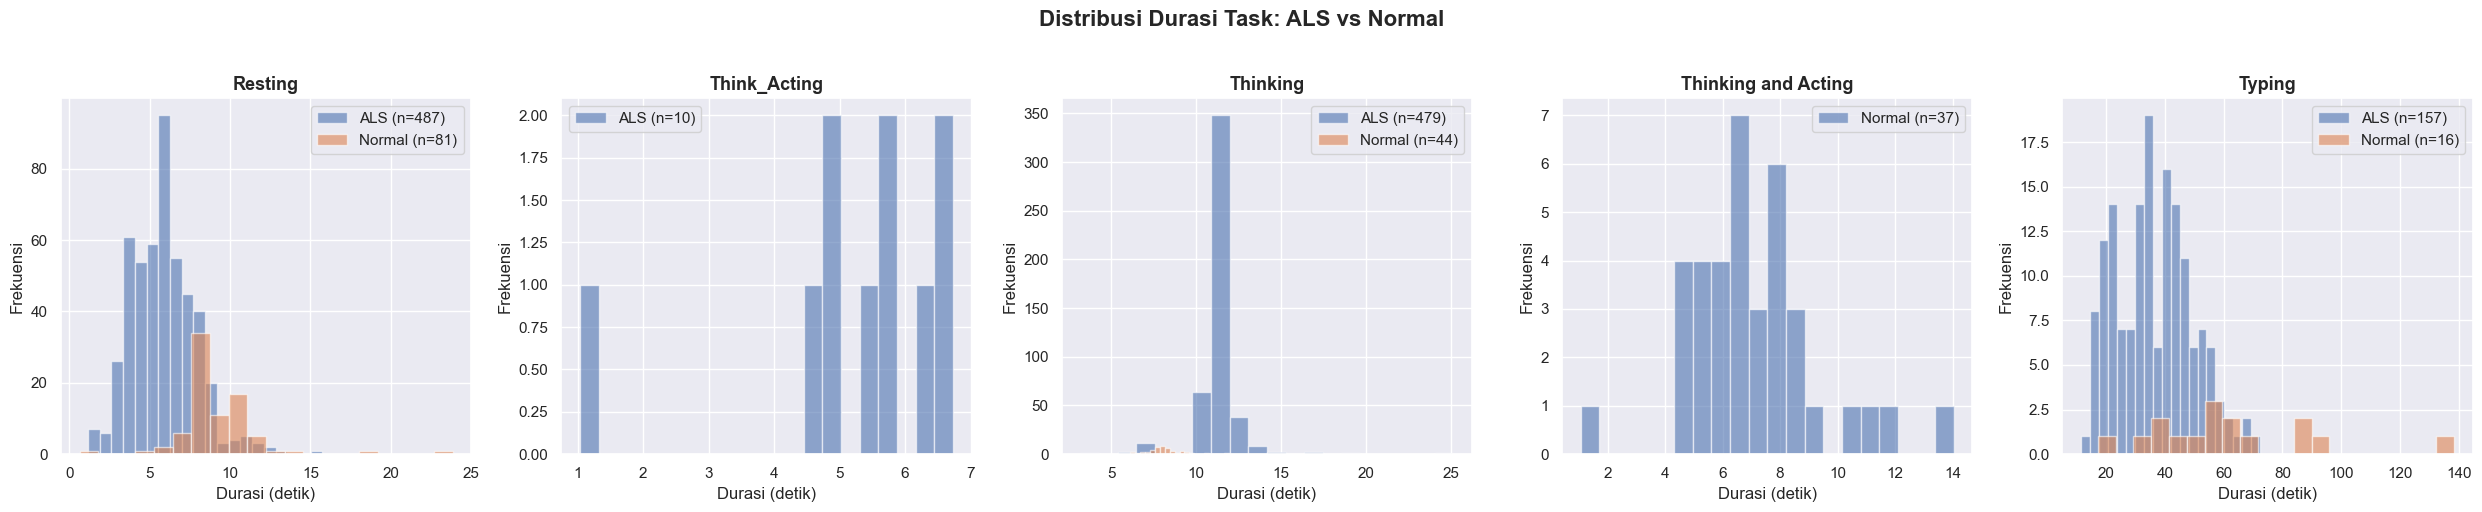

In [10]:
tasks = sorted(df['task'].unique())
n_tasks = len(tasks)

fig, axes = plt.subplots(1, n_tasks, figsize=(5 * n_tasks, 5), sharey=False)
if n_tasks == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    task_df = df[df['task'] == task]
    
    for cat in sorted(task_df['category'].unique()):
        cat_data = task_df[task_df['category'] == cat]['duration']
        ax.hist(cat_data, bins=20, alpha=0.6, label=f"{cat} (n={len(cat_data)})",
                edgecolor='white')
    
    ax.set_title(task, fontsize=13, fontweight='bold')
    ax.set_xlabel('Durasi (detik)')
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.suptitle('Distribusi Durasi Task: ALS vs Normal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Box Plot Durasi per Task & Kategori

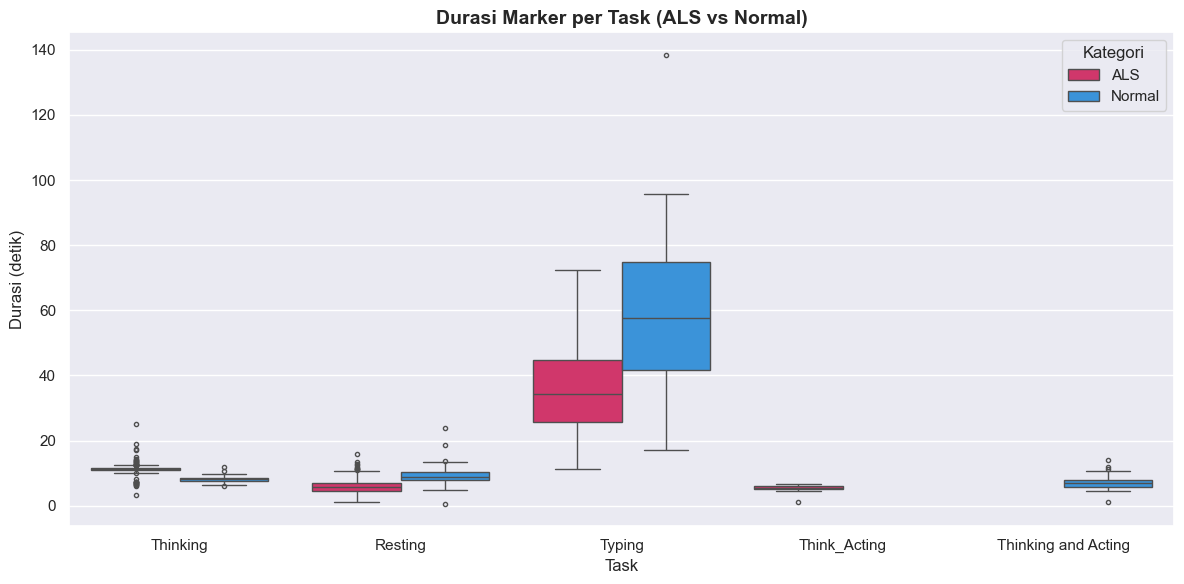

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x='task', y='duration', hue='category',
    palette={'ALS': '#E91E63', 'Normal': '#2196F3'},
    ax=ax, fliersize=3,
)

ax.set_title('Durasi Marker per Task (ALS vs Normal)', fontsize=14, fontweight='bold')
ax.set_xlabel('Task')
ax.set_ylabel('Durasi (detik)')
ax.legend(title='Kategori')
plt.tight_layout()
plt.show()

## 8. Jumlah Task per Subjek

In [12]:
task_counts = df.groupby(['subject', 'category', 'task']).size().reset_index(name='count')
pivot_counts = task_counts.pivot_table(
    index=['subject', 'category'], columns='task', values='count', fill_value=0
).reset_index()

print("Jumlah marker per subjek per task:")
display(pivot_counts)

# Cek apakah ada subjek yang punya jumlah task berbeda
print("\nSubjek dengan jumlah task tidak konsisten:")
task_cols = [c for c in pivot_counts.columns if c not in ['subject', 'category']]
for _, row in pivot_counts.iterrows():
    for tc in task_cols:
        if row[tc] == 0:
            print(f"  {row['subject']} ({row['category']}): TIDAK ADA task '{tc}'")

Jumlah marker per subjek per task:


task,subject,category,Resting,Think_Acting,Thinking,Thinking and Acting,Typing
0,ALS02,ALS,261.0,0.0,261.0,0.0,86.0
1,ALS03,ALS,226.0,10.0,218.0,0.0,71.0
2,id2,Normal,32.0,0.0,18.0,14.0,6.0
3,id3,Normal,49.0,0.0,26.0,23.0,10.0



Subjek dengan jumlah task tidak konsisten:
  ALS02 (ALS): TIDAK ADA task 'Think_Acting'
  ALS02 (ALS): TIDAK ADA task 'Thinking and Acting'
  ALS03 (ALS): TIDAK ADA task 'Thinking and Acting'
  id2 (Normal): TIDAK ADA task 'Think_Acting'
  id3 (Normal): TIDAK ADA task 'Think_Acting'


## 9. Heatmap: Jumlah Marker per Subjek

ValueError: Unknown format code 'd' for object of type 'float'

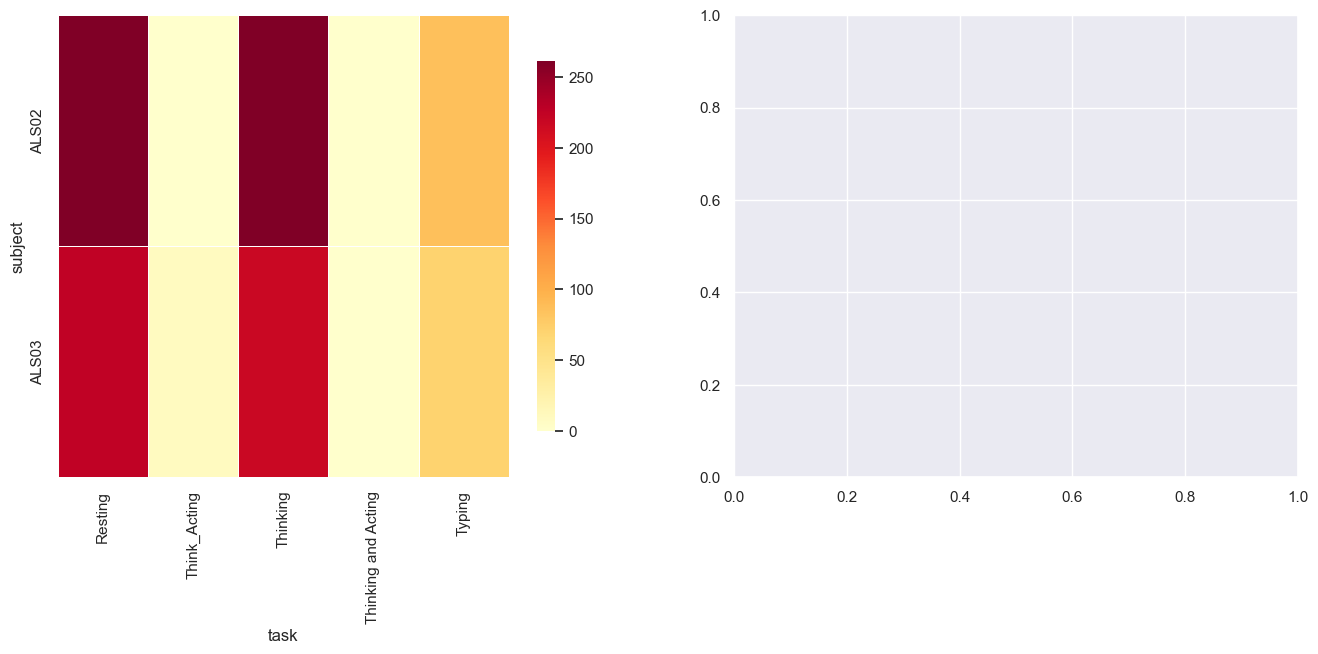

In [13]:
categories = sorted(df['category'].unique())
fig, axes = plt.subplots(1, len(categories), figsize=(8 * len(categories), max(6, len(pivot_counts) * 0.3)))

if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    cat_pivot = pivot_counts[pivot_counts['category'] == cat].set_index('subject')[task_cols]
    if cat_pivot.empty:
        ax.set_title(f'{cat} (tidak ada data)')
        continue
    
    sns.heatmap(
        cat_pivot, annot=True, fmt='d', cmap='YlOrRd',
        ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8},
    )
    ax.set_title(f'Jumlah Marker per Subjek — {cat}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Subjek')
    ax.set_xlabel('Task')

plt.tight_layout()
plt.show()

## 10. Statistik Perbandingan Durasi (ALS vs Normal)

In [15]:
from scipy.stats import mannwhitneyu, ttest_ind

print("=" * 70)
print("STATISTIK DURASI MARKER: ALS vs Normal")
print("=" * 70)

stat_rows = []
for task in sorted(df['task'].unique()):
    als_dur = df[(df['task'] == task) & (df['category'] == 'ALS')]['duration']
    nor_dur = df[(df['task'] == task) & (df['category'] == 'Normal')]['duration']
    
    row = {
        'Task': task,
        'ALS Mean (s)': f"{als_dur.mean():.2f}" if len(als_dur) else '-',
        'ALS Std': f"{als_dur.std():.2f}" if len(als_dur) else '-',
        'ALS N': len(als_dur),
        'Normal Mean (s)': f"{nor_dur.mean():.2f}" if len(nor_dur) else '-',
        'Normal Std': f"{nor_dur.std():.2f}" if len(nor_dur) else '-',
        'Normal N': len(nor_dur),
    }
    
    if len(als_dur) >= 2 and len(nor_dur) >= 2:
        _, u_p = mannwhitneyu(als_dur, nor_dur, alternative='two-sided')
        _, t_p = ttest_ind(als_dur, nor_dur)
        row['U p-value'] = f"{u_p:.4f}"
        row['T p-value'] = f"{t_p:.4f}"
        row['Signifikan?'] = 'Ya' if u_p < 0.05 else 'Tidak'
    else:
        row['U p-value'] = '-'
        row['T p-value'] = '-'
        row['Signifikan?'] = '-'
    
    stat_rows.append(row)

stat_df = pd.DataFrame(stat_rows)
display(stat_df)

STATISTIK DURASI MARKER: ALS vs Normal


,Task,ALS Mean (s),ALS Std,ALS N,Normal Mean (s),Normal Std,Normal N,U p-value,T p-value,Signifikan?
0,Resting,5.82,1.99,487,9.22,2.69,81,0.0000,0.0000,Ya
1,Think_Acting,5.22,1.63,10,-,-,0,-,-,-
2,Thinking,11.28,1.29,479,8.11,1.08,44,0.0000,0.0000,Ya
3,Thinking and Acting,-,-,0,7.07,2.35,37,-,-,-
4,Typing,36.33,12.91,157,62.23,29.63,16,0.0001,0.0000,Ya


## 11. Urutan Marker dalam File

Cek apakah urutan task dalam setiap file konsisten antara ALS dan Normal.

In [16]:
print("Urutan task per file (diurutkan berdasarkan onset):")
print("=" * 60)

sequence_counts = {}
for f in df['file'].unique():
    file_df = df[df['file'] == f].sort_values('onset')
    seq = ' -> '.join(file_df['task'].tolist())
    cat = file_df['category'].iloc[0]
    key = (cat, seq)
    sequence_counts[key] = sequence_counts.get(key, 0) + 1

for (cat, seq), count in sorted(sequence_counts.items()):
    print(f"[{cat}] ({count}x) {seq}")

Urutan task per file (diurutkan berdasarkan onset):
[ALS] (1x) Thinking
[ALS] (1x) Thinking -> Resting -> Think_Acting
[ALS] (1x) Thinking -> Resting -> Think_Acting -> Resting -> Thinking -> Resting -> Think_Acting -> Resting -> Thinking -> Resting -> Think_Acting -> Resting
[ALS] (2x) Thinking -> Resting -> Think_Acting -> Resting -> Thinking -> Resting -> Think_Acting -> Resting -> Thinking -> Resting -> Think_Acting -> Resting -> Typing
[ALS] (1x) Thinking -> Resting -> Thinking -> Resting -> Thinking -> Resting
[ALS] (155x) Thinking -> Resting -> Thinking -> Resting -> Thinking -> Resting -> Typing
[Normal] (2x) Thinking -> Resting -> Thinking -> Resting -> Thinking -> Resting -> Typing
[Normal] (1x) Thinking -> Resting -> Thinking and Acting -> Resting -> Thinking -> Resting -> Thinking and Acting -> Resting -> Thinking -> Resting -> Thinking and Acting -> Resting -> Thinking -> Resting -> Thinking and Acting -> Resting -> Typing
[Normal] (9x) Thinking -> Resting -> Thinking and 

## 12. Kesimpulan

Tulis kesimpulan kamu di sini berdasarkan hasil visualisasi di atas.

In [17]:
# Ringkasan akhir
print("RINGKASAN:")
print(f"- Total file: {df['file'].nunique()}")
print(f"- ALS: {df[df['category']=='ALS']['subject'].nunique()} subjek, "
      f"{len(df[df['category']=='ALS'])} marker")
print(f"- Normal: {df[df['category']=='Normal']['subject'].nunique()} subjek, "
      f"{len(df[df['category']=='Normal'])} marker")
print(f"- Task unik: {sorted(df['task'].unique())}")
print(f"- Durasi rata-rata keseluruhan: {df['duration'].mean():.2f} detik")

RINGKASAN:
- Total file: 176
- ALS: 2 subjek, 1133 marker
- Normal: 2 subjek, 178 marker
- Task unik: ['Resting', 'Think_Acting', 'Thinking', 'Thinking and Acting', 'Typing']
- Durasi rata-rata keseluruhan: 12.47 detik
